In [1]:
!pip install -q pandas openpyxl torch transformers scikit-learn xgboost joblib tqdm sentence-transformers shap matplotlib
!pip install -q spacy
!python -m spacy download lt_core_news_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 78.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('lt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import os
import re
import random
from collections import Counter

import joblib
import numpy as np
import pandas as pd
import torch
import shap
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
from transformers import pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier


In [3]:
# =========================
# KONFIGURACIJA
# =========================

FILE_PATH = "/content/sample_data/suzymeti.xlsx"
TEXT_COLUMN = "text"
LABEL_COLUMN = "label"

MINILM_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
SENTIMENT_MODEL_NAME = "brivil1/lithuanian-sentiment-analysis-DistilBERT"

TEST_SIZE = 0.20
RANDOM_STATE = 42
EMBED_BATCH_SIZE = 32
SENTIMENT_BATCH_SIZE = 16

MAX_WORDS = 500

CV_FOLDS = 5
ARTIFACT_DIR = "model_artifacts_minilm"
DEBUG_SAMPLE_SIZE = None

PORTAL_PATTERNS = [
    r"ekspertai\.eu",
    r"ekspertai\.live",
    r"pressjazz\.tv",
    r"respublika\.lt",
    r"lrt\.lt",
    r"15min\.lt",
    r"delfi\.lt",
    r"lrytas\.lt",
    r"zmoniu partijos",
    r"global gaze network",
    r"https?://\S+",
    r"www\.\S+",
    r"iban:\s*\S+",
    r"bic:\s*\S+",
]


In [4]:
# =========================
# REPRODUCIBILITY
# =========================

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Naudojamas įrenginys:", device)


Naudojamas įrenginys: cpu


In [5]:
# =========================
# NER: VARDŲ IR PAVARDŽIŲ ŠALINIMAS (BDAR)
# =========================

import spacy

# Krauname lietuvių kalbos modelį su NER
# Jei modelio nėra: python -m spacy download lt_core_news_sm
try:
    nlp_ner = spacy.load("lt_core_news_sm")
    print("spaCy lt_core_news_sm užkrautas.")
except OSError:
    # Atsarginė alternatyva: daugiakalbis modelis
    print("lt_core_news_sm nerastas, bandome xx_ent_wiki_sm...")
    try:
        nlp_ner = spacy.load("xx_ent_wiki_sm")
        print("xx_ent_wiki_sm užkrautas.")
    except OSError:
        nlp_ner = None
        print("⚠️  Joks spaCy NER modelis nerastas. Vardai nebus šalinami.")
        print("   Paleiskite: !python -m spacy download lt_core_news_sm")


def remove_persons(text: str) -> str:
    """Pašalina visus asmenvardžius (PERSON/PER) iš teksto naudojant NER."""
    if nlp_ner is None or not isinstance(text, str):
        return text
    doc = nlp_ner(text[:1_000_000])  # spaCy limitas
    result = text
    # Einame atvirkščiai, kad pozicijos nesislinktu
    for ent in reversed(doc.ents):
        if ent.label_ in {"PERSON", "PER"}:
            result = result[:ent.start_char] + result[ent.end_char:]
    return result


spaCy lt_core_news_sm užkrautas.


In [6]:
# =========================
# DUOMENU UZKROVIMAS IR VALYMAS
# =========================

def clean_text(text: str) -> str:
    """Salina asmenvardžius (BDAR), portalo pavadinimus, URL, autoriu prefiksus ir apriboja ilgi."""
    if not isinstance(text, str):
        return ""

    # 0. Pašalinti asmenvardžius (BDAR)
    text = remove_persons(text)

    # 1. Salinti autoriu prefiksa (pvz. "Vitas TOMKUS: ")
    text = re.sub(r'^[A-Z][a-z]+\s+[A-Z]{2,}[A-Z]*:\s*', '', text)

    # 2. Salinti portalo pavadinimus ir URL
    for pattern in PORTAL_PATTERNS:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)

    # 3. Salinti 'Susije:' fragmentus
    text = re.sub(r'Susij[eę]:.*', '', text, flags=re.IGNORECASE | re.DOTALL)

    # 4. Salinti prierasa apie draudima atgaminti
    text = re.sub(
        r'[Dd]a[zž]niausiai Lietuvoje nepageidaujama.*',
        '', text, flags=re.IGNORECASE | re.DOTALL
    )

    # 5. Salinti banko rekvizitus
    text = re.sub(r'Association.*', '', text, flags=re.IGNORECASE | re.DOTALL)

    # 6. Apriboti teksto ilgi iki MAX_WORDS zodziu
    words = text.split()
    if len(words) > MAX_WORDS:
        text = ' '.join(words[:MAX_WORDS])

    # 7. Sutvarkyti tarpus
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def load_dataset(file_path: str, text_col: str, label_col: str) -> pd.DataFrame:
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Nerastas failas: {file_path}\n"
            "Atnaujinkite FILE_PATH reiksme pagal savo aplinka."
        )

    df = pd.read_excel(file_path)

    missing_cols = [c for c in [text_col, label_col] if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Truksta stulpeliu: {missing_cols}")

    df = df[[text_col, label_col]].copy()
    df = df.dropna(subset=[text_col, label_col])
    df[text_col] = df[text_col].astype(str)
    df[label_col] = df[label_col].astype(int)

    if DEBUG_SAMPLE_SIZE is not None:
        df = df.sample(min(DEBUG_SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)

    return df.reset_index(drop=True)


df = load_dataset(FILE_PATH, TEXT_COLUMN, LABEL_COLUMN)

print("Valomas tekstas...")
df[TEXT_COLUMN] = df[TEXT_COLUMN].apply(clean_text)

before = len(df)
df = df[df[TEXT_COLUMN].str.strip().str.len() > 20].reset_index(drop=True)
print(f"Pasalinta {before - len(df)} tuščiu irasu po valymo")

print("\nDuomenu forma:", df.shape)
print("\nLabel pasiskirstymas:")
print(df[LABEL_COLUMN].value_counts().sort_index())
print("\nPavyzdys po valymo:")
display(df[[TEXT_COLUMN, LABEL_COLUMN]].head(3))


Valomas tekstas...
Pasalinta 0 tuščiu irasu po valymo

Duomenu forma: (510, 2)

Label pasiskirstymas:
label
0    255
1    255
Name: count, dtype: int64

Pavyzdys po valymo:


,text,label
0,Karas Ukrainoje Rusijai yra „egzistencinis“ kl...,0
1,ŠLYKŠČIAUSIAS UKRAINOS KARAS. Ir kokių karų mū...,0
2,"Geriau gyva Ukraina, negu jokios Ukrainos. Sun...",0


In [7]:
# =========================
# IŠVALYTŲ DUOMENŲ IŠSAUGOJIMAS (BDAR)
# =========================

import os

CLEANED_OUTPUT_PATH = FILE_PATH.replace(".xlsx", "_išvalyta.xlsx")

df[[TEXT_COLUMN, LABEL_COLUMN]].to_excel(CLEANED_OUTPUT_PATH, index=False)

print(f"✅ Išvalyta duomenų aibė išsaugota: {CLEANED_OUTPUT_PATH}")
print(f"   Įrašų: {len(df)}")
print(f"   Stulpeliai: {list(df[[TEXT_COLUMN, LABEL_COLUMN]].columns)}")


✅ Išvalyta duomenų aibė išsaugota: /content/sample_data/suzymeti_išvalyta.xlsx
   Įrašų: 510
   Stulpeliai: ['text', 'label']


In [8]:
# =========================
# VIENAS SPLITAS VISIEMS EKSPERIMENTAMS
# =========================

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[LABEL_COLUMN]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_train_text = train_df[TEXT_COLUMN].tolist()
X_test_text = test_df[TEXT_COLUMN].tolist()

y_train = train_df[LABEL_COLUMN].to_numpy()
y_test = test_df[LABEL_COLUMN].to_numpy()

print("Train dydis:", len(train_df))
print("Test dydis: ", len(test_df))


Train dydis: 408
Test dydis:  102


## Stilistinės feature'os

In [9]:
def safe_div(a, b):
    return float(a) / float(b) if b else 0.0


def count_keyword_hits(tokens, lexicon):
    return sum(1 for token in tokens if token in lexicon)


def extract_stylistic_features(text: str):
    if not isinstance(text, str):
        text = ""

    text = text.strip()
    words = text.split()
    num_words = len(words)
    num_chars = len(text)

    normalized_words = re.findall(r"\w+", text.lower(), flags=re.UNICODE)
    num_tokens = len(normalized_words)

    sentences = re.split(r"[.!?]+", text)
    sentences = [s.strip() for s in sentences if s.strip()]
    sentence_lengths = [len(re.findall(r"\w+", s, flags=re.UNICODE)) for s in sentences]
    num_sentences = len(sentence_lengths) if sentence_lengths else 1

    avg_word_len = np.mean([len(w) for w in normalized_words]) if normalized_words else 0.0
    avg_sentence_len = np.mean(sentence_lengths) if sentence_lengths else 0.0
    sentence_len_std = np.std(sentence_lengths) if len(sentence_lengths) > 1 else 0.0

    exclamation_count = text.count("!")
    question_count = text.count("?")
    interrobang_count = len(re.findall(r"[!?]{2,}", text))
    ellipsis_count = text.count("...")
    comma_count = text.count(",")
    dot_count = text.count(".")
    colon_count = text.count(":")
    semicolon_count = text.count(";")
    dash_count = text.count("-") + text.count("–") + text.count("—")
    newline_count = text.count("\n")

    digit_count = sum(ch.isdigit() for ch in text)
    percent_count = text.count("%")
    url_count = len(re.findall(r"(https?://\S+|www\.\S+)", text.lower()))
    email_like_count = len(re.findall(r"\b\S+@\S+\.\S+\b", text.lower()))
    quote_count = (text.count('"') + text.count("'") + text.count("„")
                   + text.count("“") + text.count("‘") + text.count("’"))

    letters = [ch for ch in text if ch.isalpha()]
    uppercase_ratio = safe_div(sum(ch.isupper() for ch in letters), len(letters))

    uppercase_words = [
        w for w in re.findall(r"\b[\wĄČĘĖĮŠŲŪŽ]+\b", text, flags=re.UNICODE)
        if len(w) >= 2 and any(ch.isalpha() for ch in w) and w.isupper()
    ]
    uppercase_word_ratio = safe_div(len(uppercase_words), num_tokens)

    repeated_punct_count = len(re.findall(r'([!?.,:;])\1+', text))
    repeated_char_count = len(re.findall(r'([A-Za-zĄČĘĖĮŠŲŪŽąčęėįšųūž])\1{2,}', text))

    # FIX: O(n) vietoj O(n^2) - Counter naudojamas hapax skaiciavimui
    word_counts = Counter(normalized_words)
    unique_word_ratio = safe_div(len(word_counts), num_tokens)
    hapax_ratio = safe_div(sum(1 for c in word_counts.values() if c == 1), num_tokens)

    short_word_ratio = safe_div(sum(len(w) <= 3 for w in normalized_words), num_tokens)
    long_word_ratio = safe_div(sum(len(w) >= 8 for w in normalized_words), num_tokens)

    punctuation_count = sum(ch in r"""!?,.:;"'()-–—[]{}""" for ch in text)
    punctuation_density = safe_div(punctuation_count, max(num_chars, 1))
    digit_ratio = safe_div(digit_count, max(num_chars, 1))
    avg_token_repetition = 1.0 - unique_word_ratio if num_tokens else 0.0

    first_person_words = {
        "aš", "mes", "mano", "mūsų", "man", "mums", "mane", "mus", "mudu", "mudvi"
    }
    second_person_words = {
        "tu", "jūs", "tavo", "jūsų", "tau", "jums", "tave", "jus"
    }
    intensifier_words = {
        "labai", "visiškai", "ypač", "itin", "be galo", "kraupiai", "nepaprastai", "tikrai", "akivaizdžiai"
    }
    certainty_words = {
        "visada", "niekada", "neabejotinai", "akivaizdu", "tikrai", "būtinai", "abejonių nėra", "be abejonės"
    }

    first_person_ratio = safe_div(count_keyword_hits(normalized_words, first_person_words), num_tokens)
    second_person_ratio = safe_div(count_keyword_hits(normalized_words, second_person_words), num_tokens)
    intensifier_ratio = safe_div(count_keyword_hits(normalized_words, intensifier_words), num_tokens)
    certainty_ratio = safe_div(count_keyword_hits(normalized_words, certainty_words), num_tokens)

    return [
        num_words, num_chars, num_sentences,
        avg_word_len, avg_sentence_len, sentence_len_std,
        exclamation_count, question_count, interrobang_count, ellipsis_count,
        comma_count, dot_count, colon_count, semicolon_count, dash_count, newline_count,
        digit_count, percent_count, url_count, email_like_count,
        uppercase_ratio, uppercase_word_ratio, quote_count,
        repeated_punct_count, repeated_char_count,
        unique_word_ratio, hapax_ratio, short_word_ratio, long_word_ratio,
        punctuation_density, digit_ratio, avg_token_repetition,
        first_person_ratio, second_person_ratio, intensifier_ratio, certainty_ratio,
    ]


STYLISTIC_COLUMNS = [
    "num_words", "num_chars", "num_sentences",
    "avg_word_len", "avg_sentence_len", "sentence_len_std",
    "exclamation_count", "question_count", "interrobang_count", "ellipsis_count",
    "comma_count", "dot_count", "colon_count", "semicolon_count", "dash_count", "newline_count",
    "digit_count", "percent_count", "url_count", "email_like_count",
    "uppercase_ratio", "uppercase_word_ratio", "quote_count",
    "repeated_punct_count", "repeated_char_count",
    "unique_word_ratio", "hapax_ratio", "short_word_ratio", "long_word_ratio",
    "punctuation_density", "digit_ratio", "avg_token_repetition",
    "first_person_ratio", "second_person_ratio", "intensifier_ratio", "certainty_ratio",
]


def build_stylistic_matrix(texts):
    return np.array([extract_stylistic_features(text) for text in texts], dtype=np.float32)


X_train_style = build_stylistic_matrix(X_train_text)
X_test_style = build_stylistic_matrix(X_test_text)

print("Train stilistika:", X_train_style.shape)
print("Test stilistika: ", X_test_style.shape)
display(pd.DataFrame(X_train_style, columns=STYLISTIC_COLUMNS).head())


Train stilistika: (408, 36)
Test stilistika:  (102, 36)


,num_words,num_chars,num_sentences,avg_word_len,avg_sentence_len,sentence_len_std,exclamation_count,question_count,interrobang_count,ellipsis_count,...,hapax_ratio,short_word_ratio,long_word_ratio,punctuation_density,digit_ratio,avg_token_repetition,first_person_ratio,second_person_ratio,intensifier_ratio,certainty_ratio
0,498.0,4112.0,33.0,6.857422,15.515152,8.079609,0.0,2.0,0.0,0.0,...,0.435547,0.181641,0.382812,0.021401,0.000973,0.392578,0.001953,0.0,0.001953,0.000000
1,111.0,909.0,5.0,7.175926,21.600000,8.522910,0.0,0.0,0.0,0.0,...,0.657407,0.138889,0.490741,0.019802,0.000000,0.222222,0.000000,0.0,0.000000,0.000000
2,431.0,3064.0,29.0,6.028503,14.517241,6.961077,0.0,0.0,0.0,0.0,...,0.467934,0.194774,0.296912,0.026110,0.006854,0.356295,0.011876,0.0,0.004751,0.002375
3,267.0,1901.0,14.0,5.912879,18.857143,9.583148,0.0,1.0,0.0,0.0,...,0.602273,0.257576,0.291667,0.029984,0.008943,0.268939,0.003788,0.0,0.003788,0.000000
4,54.0,395.0,7.0,4.953125,9.142858,5.642405,2.0,1.0,0.0,0.0,...,0.796875,0.359375,0.203125,0.027848,0.022785,0.109375,0.000000,0.0,0.000000,0.000000


## Sentimento modelis

In [10]:
print("Kraunamas sentiment modelis...")
sentiment_pipe = pipeline(
    task="text-classification",
    model=SENTIMENT_MODEL_NAME,
    tokenizer=SENTIMENT_MODEL_NAME,
    top_k=None,
    truncation=True,
    padding=True,
    max_length=512,
    device=0 if torch.cuda.is_available() else -1
)
print("Sentiment modelis užkrautas.")


Kraunamas sentiment modelis...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

Sentiment modelis užkrautas.


In [ ]:
def normalize_sentiment_scores(result):
    score_map = {}
    for item in result:
        label = str(item['label']).strip().lower()
        score_map[label] = float(item['score'])

    neg = score_map.get('neigiamas', score_map.get('negative', 0.0))
    neu = score_map.get('neutralus', score_map.get('neutral', 0.0))
    pos = score_map.get('teigiamas', score_map.get('positive', 0.0))
    return neg, neu, pos


EMOTION_LEXICONS = {
    'fear': {
        'baimė',      # baimė, baimės
        'bij',        # bijo, bijau, bijok, bijoti
        'grėsm',      # grėsmė, grėsmingas, grėsminga
        'pavojus',    # pavojus
        'pavojing',   # pavojingas, pavojinga
        'katastro',   # katastrofa, katastrofiškas
        'siaub',      # siaubas, siaubingas
        'šokiruoj',   # šokiruojantis, šokiruoja
        'panik',      # panika, panikos
        'mirtin',     # mirtina, mirtinas
        'mirtis',     # mirtis
        'kriz',       # krizė, krizės
        'žlug',       # žlugimas, žlugs, žlugo
        'sunaikin',   # sunaikins, sunaikino, sunaikinimas
        'apokalips',  # apokalipsė, apokalipsės
        'teror',      # teroras, teroristai, terorizmas
        'okupa',      # okupacija, okupantas
        'genocid',    # genocidas, genocido
        'tragedi',    # tragedija, tragedijos
        'nelaimė',    # nelaimė, nelaimės
        'pralaimėj',  # pralaimėjimas, pralaimėjo
        'sugriov',    # sugriovimas, sugriovė
        'žūtbūtin',   # žūtbūtinis, žūtbūtinė
    },
    'anger': {
        # Pyktis, pasipiktinimas
        'pyk',        # pyktis, pykčio, pyksta
        'pikt',       # piktina, piktinasi, piktinantis, piktas, piktintis
        'mel',        # meluoja, melavo, melagis, melagiai, melaginga
        'išdav',      # išdavystė, išdavikas, išdavikai, išdavė
        'apgavyst',   # apgavystė, apgavystės
        'koru',      # korumpuotas, korupcija, korupcijos
        'gėd',        # gėda, gėdingas, gėdinga, gėdingai
        'pasipiktin', # pasipiktinimas, pasipiktino
        'nusikalt',   # nusikaltimas, nusikaltėlis
        'sukč',       # sukčius, sukčiai, sukčiavimas
        'vog', 'vag', # vogė, vogti, vagystė, vagis
        'kolaborant', # kolaborantas, kolaborantai
        'budel',      # budelis, budeliai
        'reket',      # reketas, reketai
        'lupik',      # lupikas, lupikavimas
        'afer',       # afera, aferistas, aferistai
        'niekš',      # niekšas, niekšai, niekšiškas
        'skandal',    # skandalas, skandalo, skandalingas
        'šlykšt', #šlykštu, šlykštūs, šlykštus
        'apgailėt', #aapgailėtina, apgailėtinas
          },
    'urgency': {
            # Skubumas, raginimas
        'skub',       # skubiai, skubu, skubėkite, skubėk, skubus
        'nedels',    # nedelsiant, nedelsdami
        'tuoj',     # tuojau, tuoj pat
        'dabar pat',
        'paskubėk',   # paskubėk, paskubėkite
        'platin',     # platink, platinkite
        'įspėj',      # įspėjimas, įspėjame, įspėja
        'neatidėliot', # neatidėliotinas, neatidėliotina
        'kol nevėlu',
        'paskutinė galimybė',
        'paskutinis šansas',
        'dabar arba niekada',
        'privalai žinoti',
        'privalote žinoti',
    },
    'certainty': {
        'neabejot',   # neabejotinai, neabejotinas, neabejotina, neabejokite, neabejoti
        'akivaizdž',  # akivaizdžiai
        'akivaizd',   # akivaizdu, akivaizdus, akivaizdi
        'be abejonės',
        'be jokios abejonės',
        'nekyla abejonių',
        'aišku kaip dieną',
        'šimtu procentų',
        'neginčijam',  # neginčijamai, neginčijamas
        'absoliuč',    # absoliučiai
        'absoliut',    # absoliutus, absoliuti
        'garantuot',   # garantuotai, garantuotas
        'įrodyt',      # įrodyta, įrodytas
    },
    'conspiracy': {
        'slapt',      # slapta, slaptasis, slaptoji, slaptai
        'slepi',      # slepia, slepiama
        'nuslėp',     # nuslėpė, nuslėpta
        'nuslepi',    # nuslepia
        'užkulis',    # užkulisiai, užkulisiuose, užkulisių
        'kontrol',# kontroliuoja, kontroliuojami, kontrolė, kontrolės
        'manipul',# manipuliacija, manipuliuoja
        'elit',       # elitai, elito, elitas
        'globalist',  # globalistai, globalistas, globalistė
        'režim',      # režimas, režimo
        'marionet',   # marionetė, marionetės
        'tikrasis tikslas',
        'tikroji darbotvarkė',
        'nematoma ranka',
        'šešėlinė valdžia',
        'slaptosios jėgos',
        'tikrieji šeimininkai',
        'degut', #deguto šaukštas, degutas

    },
    'clickbait': {
        # Sensacingumas, klikbeitai
        'šokiruoj',   # šokiruoja, šokiruojantis, šokiruojanti
        'neįtikėti', # neįtikėtina, neįtikėtinas
        'sensaci',   # sensacija, sensacinga, sensacingas, sensacingai
        'stulbinan',  # stulbinanti, stulbinantis, stulbinančiai
        'nepatikės',
        'negalėsi patikėti',
        'atskleist',  # atskleista, atskleidė
        'pagaliau atskleista',
        'skandal', # skandalinga, skandalingas, skandalas
        'nepamatysite',
        'niekur nerasite',
        'svarbu žinoti',
        'privaloma perskaityti',
        'tiesa apie',
        'tikroji tiesa',
        'visi kalba',
        'priblošk',  # pribloškia, pribloškiantis
    },
    'propaganda': {
        # Propagandinė retorika
        'vatinuk',    # vatinukai, vatinukas
        'vatnik',     # vatnikas, vatnikė
        'kraujočiuot',# kraujočiuotojas, kraujočiuotojai
        'berašč',     # berašciai
        'klan', # klanas, klanai, klano
        'sistemin',   # sisteminiai, sisteminė žiniasklaida
        'proxy karas',
        'išprovok',# išprovokuotas,išprovokavo, išprovokavimas
        'anglosaks',  # anglosaksai, anglosaksų
        'vasal',      # vasalai, vasalinė
        'globalist',  # globalistai, globalistinė, globalistas
        'marionet', # marionetiška vyriausybė
        'vakarų pakalik',
        'mokesčių mokėtojų pinigais',
    },
    'kremlius_naratyvai': {
        # Kremliaus naratyvai
        'išprovok',        # išprovokavo, išprovokavimas
        'brolžudiš',       # brolžudiška, brolžudiškas
        'nato plėtr',      # nato plėtra, nato plėtros
        'nato ekspansij',  # nato ekspansija
        'rusofob',         # rusofobija, rusofobus, rusofobiška
        'pasaulio perdalin',# pasaulio perdalinimas
        'kolektyvin',      # kolektyviniai vakarai
        'specialioji operacij', # specialioji operacija
        'specialiosios operacij',
        'denacifikacij',   # denacifikacija
        'ukronac',         # ukronaciai
        'slavų vienybė',
        'slaviškos šaknys',
        'anglosaksų provokacij',
        'marionet',
        'naciai',
        'genocid',
    },
}


def count_phrase_hits(text_lower: str, lexicon):
    return sum(text_lower.count(term) for term in lexicon if ' ' in term)


def count_token_hits(tokens, lexicon):
    stems = {s for s in lexicon if ' ' not in s}
    return sum(1 for token in tokens if any(token.startswith(stem) for stem in stems))


def extract_emotion_features_from_text(text: str, neg: float, neu: float, pos: float):
    if not isinstance(text, str):
        text = ''

    text_lower = text.lower()
    tokens = re.findall(r'\w+', text_lower, flags=re.UNICODE)
    token_count = len(tokens)

    fear_hits       = count_token_hits(tokens, EMOTION_LEXICONS['fear'])       + count_phrase_hits(text_lower, EMOTION_LEXICONS['fear'])
    anger_hits      = count_token_hits(tokens, EMOTION_LEXICONS['anger'])      + count_phrase_hits(text_lower, EMOTION_LEXICONS['anger'])
    urgency_hits    = count_token_hits(tokens, EMOTION_LEXICONS['urgency'])    + count_phrase_hits(text_lower, EMOTION_LEXICONS['urgency'])
    certainty_hits  = count_token_hits(tokens, EMOTION_LEXICONS['certainty'])  + count_phrase_hits(text_lower, EMOTION_LEXICONS['certainty'])
    conspiracy_hits = count_token_hits(tokens, EMOTION_LEXICONS['conspiracy']) + count_phrase_hits(text_lower, EMOTION_LEXICONS['conspiracy'])
    clickbait_hits  = count_token_hits(tokens, EMOTION_LEXICONS['clickbait'])  + count_phrase_hits(text_lower, EMOTION_LEXICONS['clickbait'])
    propaganda_hits = count_token_hits(tokens, EMOTION_LEXICONS['propaganda']) + count_phrase_hits(text_lower, EMOTION_LEXICONS['propaganda'])
    kremlius_hits   = count_token_hits(tokens, EMOTION_LEXICONS['kremlius_naratyvai']) + count_phrase_hits(text_lower, EMOTION_LEXICONS['kremlius_naratyvai'])

    caps_words   = len(re.findall(r'\b[A-ZĄČĘĖĮŠŲŪŽ]{3,}\b', text))
    exclamations = text.count('!')
    rhetorical_q = text.count('?')
    ellipsis_count = text.count('...')
    quote_marks  = text.count('\u201e') + text.count('\u201c') + text.count('"')

    subjectivity_signal = urgency_hits + certainty_hits + clickbait_hits + propaganda_hits + exclamations + caps_words
    emotional_intensity = neg + pos
    sentiment_polarity  = pos - neg
    sentiment_confidence = max(neg, neu, pos)
    sentiment_entropy   = -sum(p * np.log(p + 1e-12) for p in [neg, neu, pos])
    punctuation_emotion_ratio = safe_div(exclamations + rhetorical_q, max(len(text), 1))
    manipulation_score  = safe_div(propaganda_hits + kremlius_hits + conspiracy_hits, max(token_count, 1))

    return [
        neg, neu, pos,
        sentiment_polarity, emotional_intensity, sentiment_confidence, sentiment_entropy,
        safe_div(fear_hits, token_count),
        safe_div(anger_hits, token_count),
        safe_div(urgency_hits, token_count),
        safe_div(certainty_hits, token_count),
        safe_div(conspiracy_hits, token_count),
        safe_div(clickbait_hits, token_count),
        safe_div(subjectivity_signal, max(token_count, 1)),
        punctuation_emotion_ratio,
        safe_div(propaganda_hits, token_count),
        safe_div(kremlius_hits, token_count),
        manipulation_score,
        safe_div(caps_words, max(token_count, 1)),
        safe_div(exclamations, max(token_count, 1)),
        safe_div(rhetorical_q, max(token_count, 1)),
        safe_div(ellipsis_count, max(token_count, 1)),
        safe_div(quote_marks, max(token_count, 1)),
    ]


SENTIMENT_COLUMNS = [
    'sent_neg', 'sent_neu', 'sent_pos',
    'sent_polarity', 'emotional_intensity', 'sentiment_confidence', 'sentiment_entropy',
    'fear_ratio', 'anger_ratio', 'urgency_ratio', 'certainty_ratio',
    'conspiracy_ratio', 'clickbait_ratio', 'subjectivity_signal_ratio', 'punctuation_emotion_ratio',
    'propaganda_ratio', 'kremlius_ratio', 'manipulation_score',
    'caps_words_ratio', 'exclamation_ratio', 'rhetorical_q_ratio',
    'ellipsis_ratio', 'quote_ratio',
]


def extract_sentiment_features(texts, batch_size=SENTIMENT_BATCH_SIZE):
    features = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Sentiment'):
        batch = texts[i:i + batch_size]
        results = sentiment_pipe(batch)
        for text, result in zip(batch, results):
            neg, neu, pos = normalize_sentiment_scores(result)
            features.append(extract_emotion_features_from_text(text, neg, neu, pos))
    return np.array(features, dtype=np.float32)


X_train_sent = extract_sentiment_features(X_train_text)
X_test_sent = extract_sentiment_features(X_test_text)

print('Train sentiment/emocijos:', X_train_sent.shape)
print('Test sentiment/emocijos: ', X_test_sent.shape)
display(pd.DataFrame(X_train_sent, columns=SENTIMENT_COLUMNS).head())


Sentiment:   0%|          | 0/26 [00:00<?, ?it/s]

Sentiment:   0%|          | 0/7 [00:00<?, ?it/s]

## MiniLM embeddings

In [ ]:
print("Kraunamas MiniLM modelis...")
minilm_model = SentenceTransformer(MINILM_MODEL_NAME)
print("MiniLM modelis užkrautas.")


In [ ]:
def extract_minilm_embeddings(texts, batch_size=EMBED_BATCH_SIZE):
    """
    Generuoja MiniLM embeddingus visiems tekstams.
    Grazina (N, 384) matrica.
    """
    embeddings = minilm_model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    return embeddings.astype(np.float32)


X_train_embed = extract_minilm_embeddings(X_train_text)
X_test_embed = extract_minilm_embeddings(X_test_text)

print("Train MiniLM:", X_train_embed.shape)
print("Test MiniLM: ", X_test_embed.shape)


## Galutinis modelis (M3: MiniLM + emocijos + stilistika)


In [ ]:
# Galutinis feature rinkinys: MiniLM + emocijos + stilistika
X_train_m3 = np.hstack([X_train_embed, X_train_sent, X_train_style])
X_test_m3  = np.hstack([X_test_embed,  X_test_sent,  X_test_style])

print("Train M3:", X_train_m3.shape)
print("Test M3: ", X_test_m3.shape)


## Modelio apmokymas


In [ ]:
def make_model(model_type: str):
    if model_type == "lr":
        return LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE
        )
    if model_type == "rf":
        return RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    if model_type == "xgb":
        return XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    raise ValueError(f"Nežinomas modelio tipas: {model_type}")


def train_and_evaluate(X_train, X_test, y_train, y_test, model_type="lr"):
    scaler = None

    if model_type in {"lr", "svm"}:
        scaler = StandardScaler()
        X_train_used = scaler.fit_transform(X_train)
        X_test_used = scaler.transform(X_test)
    else:
        X_train_used = X_train
        X_test_used = X_test

    model = make_model(model_type)
    model.fit(X_train_used, y_train)
    preds = model.predict(X_test_used)

    return {
        "model": model,
        "scaler": scaler,
        "accuracy": accuracy_score(y_test, preds),
        "f1_weighted": f1_score(y_test, preds, average="weighted"),
        "report": classification_report(y_test, preds, digits=4)
    }


# =========================
# GALUTINIO MODELIO APMOKYMAS (XGBoost, M3)
# =========================

best_model_key    = "xgb"
best_variant_key  = "m3"

final_result = train_and_evaluate(
    X_train_m3, X_test_m3,
    y_train, y_test,
    model_type=best_model_key
)

print("Accuracy :", round(final_result['accuracy'], 4))
print("F1       :", round(final_result['f1_weighted'], 4))


## Artefaktų išsaugojimas

In [ ]:
import os, joblib

os.makedirs(ARTIFACT_DIR, exist_ok=True)

bundle = {
    "best_variant_key"  : best_variant_key,
    "best_model_key"    : best_model_key,
    "best_variant_label": "M3: MiniLM + emocijos + stilistika",
    "best_model_label"  : "XGBoost",
    "model"             : final_result["model"],
    "scaler"            : final_result["scaler"],
    "minilm_model_name" : MINILM_MODEL_NAME,
    "config": {
        "TEXT_COLUMN"          : TEXT_COLUMN,
        "LABEL_COLUMN"         : LABEL_COLUMN,
        "MINILM_MODEL_NAME"    : MINILM_MODEL_NAME,
        "SENTIMENT_MODEL_NAME" : SENTIMENT_MODEL_NAME,
        "EMBED_BATCH_SIZE"     : EMBED_BATCH_SIZE,
        "SENTIMENT_BATCH_SIZE" : SENTIMENT_BATCH_SIZE,
        "RANDOM_STATE"         : RANDOM_STATE,
        "MAX_WORDS"            : MAX_WORDS,
        "STYLISTIC_COLUMNS"    : STYLISTIC_COLUMNS,
    },
}

bundle_path = os.path.join(ARTIFACT_DIR, "best_model_bundle_minilm.joblib")
joblib.dump(bundle, bundle_path)
print("Issaugota:", bundle_path)


## SHAP interpretacija ir prognozė

**FIX:** `TreeExplainer` sukuriamas vieną kartą globaliai, o ne iš naujo kiekvieno `predict_with_explanation()` iškvietimo metu.

In [ ]:
# SHAP explainer sukuriamas vieną kartą globaliai
import shap

best_xgb_model = final_result['model']

X_test_m3  = np.hstack([X_test_embed,  X_test_sent,  X_test_style])
X_train_m3 = np.hstack([X_train_embed, X_train_sent, X_train_style])

print('Modelis:', type(best_xgb_model))
print('X_test forma:', X_test_m3.shape)

shap_explainer = shap.TreeExplainer(best_xgb_model)
print('SHAP explainer sukurtas.')


TEKSTAS: „„ Paramą Ukrainos kariniams daliniams siunčia ir žemdirbiai. Tačiau kartu ir nerimas – kyla degalų, trąšų kainos. Ukrai...
SPRENDIMAS:    TIESA
PASITIKEJIMAS: 82.4%
  P(dezinformacija): 17.6%
  P(tiesa):          82.4%

KOMPONENTU INDELIS I SPRENDIMA:
  Semantika  : 77.4%
  Emocijos   : 18.5%
  Stilistika : 4.0%


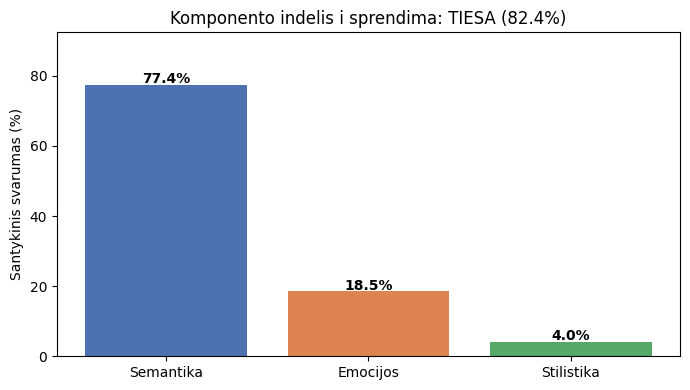


SVARBIAUSI EMOCIJU RODIKLIAI:
  (palyginimui - dezinformacijos klases vidurkis)
  Skyrybos/emociju santykis: 0.0000  (priesinga klase: 0.0009)
  Pykcio leksika: 0.0000  (priesinga klase: 0.0027)
  Retoriniu klausimu daznis: 0.0000  (priesinga klase: 0.0056)
  Kabuciu daznis: 0.0369  (priesinga klase: 0.0306)
  Manipuliacijos indeksas: 0.0000  (priesinga klase: 0.0031)

SVARBIAUSI STILISTIKOS RODIKLIAI:
  (palyginimui - dezinformacijos klases vidurkis)
  Klausimu skaicius: 0.0000  (priesinga klase: 2.2745)
  Kableliu skaicius: 81.0000  (priesinga klase: 40.6422)
  Skyrybos tankis: 0.0386  (priesinga klase: 0.0289)
  Sakiniu ilgio dispersija: 6.0389  (priesinga klase: 8.8782)
  Didziuju raidziu santykis: 0.0228  (priesinga klase: 0.0335)


In [20]:
# =============================================
# LIETUVISKI PAVADINIMAI
# =============================================

SENT_LT = {
    'sent_neg': 'Neigiamas sentimentas',
    'sent_neu': 'Neutralus sentimentas',
    'sent_pos': 'Teigiamas sentimentas',
    'sent_polarity': 'Sentimento poliarumas',
    'emotional_intensity': 'Emocinis intensyvumas',
    'sentiment_confidence': 'Sentimento pasitikejimas',
    'sentiment_entropy': 'Sentimento entropija',
    'fear_ratio': 'Baimes leksika',
    'anger_ratio': 'Pykcio leksika',
    'urgency_ratio': 'Skubumo leksika',
    'certainty_ratio': 'Tikrumo leksika',
    'conspiracy_ratio': 'Samokslo leksika',
    'clickbait_ratio': 'Sensacingumo leksika',
    'subjectivity_signal_ratio': 'Subjektyvumo signalas',
    'punctuation_emotion_ratio': 'Skyrybos/emociju santykis',
    'propaganda_ratio': 'Propagandos leksika',
    'kremlius_ratio': 'Kremliaus naratyvu leksika',
    'manipulation_score': 'Manipuliacijos indeksas',
    'caps_words_ratio': 'Didziuju raidziu daznis',
    'exclamation_ratio': 'Sauktuku daznis',
    'rhetorical_q_ratio': 'Retoriniu klausimu daznis',
    'ellipsis_ratio': 'Daugtaskiu daznis',
    'quote_ratio': 'Kabuciu daznis',
}

STYLE_LT = {
    'num_words': 'Zodziu skaicius',
    'num_chars': 'Simboliu skaicius',
    'num_sentences': 'Sakiniu skaicius',
    'avg_word_len': 'Vidutinis zodzio ilgis',
    'avg_sentence_len': 'Vidutinis sakinio ilgis',
    'sentence_len_std': 'Sakiniu ilgio dispersija',
    'exclamation_count': 'Sauktuku skaicius',
    'question_count': 'Klausimu skaicius',
    'interrobang_count': 'Dvigubu skyrybos zenklu sk.',
    'ellipsis_count': 'Daugtaskiu skaicius',
    'comma_count': 'Kableliu skaicius',
    'dot_count': 'Tasku skaicius',
    'semicolon_count': 'Kabliataskiu skaicius',
    'dash_count': 'Bruksniu skaicius',
    'newline_count': 'Nauju eiluciu skaicius',
    'digit_count': 'Skaitmenu skaicius',
    'percent_count': 'Procentu zenklu skaicius',
    'url_count': 'URL skaicius',
    'email_like_count': 'El. pasto adresu skaicius',
    'uppercase_ratio': 'Didziuju raidziu santykis',
    'uppercase_word_ratio': 'Didziosiomis rastytu zodziu santykis',
    'quote_count': 'Kabuciu skaicius',
    'repeated_punct_count': 'Pasikartojanciu skyrybos zenklu sk.',
    'repeated_char_count': 'Pasikartojanciu simboliu skaicius',
    'unique_word_ratio': 'Unikaliu zodziu santykis',
    'hapax_ratio': 'Zodziai pasikartojantys viena karta',
    'short_word_ratio': 'Trumpu zodziu santykis',
    'long_word_ratio': 'Ilgu zodziu santykis',
    'punctuation_density': 'Skyrybos tankis',
    'digit_ratio': 'Skaitmenu santykis',
    'avg_token_repetition': 'Zodziu pasikartojimas',
    'first_person_ratio': 'Pirmojo asmens zodziai',
    'second_person_ratio': 'Antrojo asmens zodziai',
    'intensifier_ratio': 'Stiprinanciu zodziu santykis',
    'certainty_ratio': 'Tikrumo zodziu santykis',
}

# =============================================
# VIDURKIAI PAGAL KLASE (vieną kartą)
# =============================================

df_train_sent  = pd.DataFrame(X_train_sent, columns=SENTIMENT_COLUMNS)
df_train_style = pd.DataFrame(X_train_style, columns=STYLISTIC_COLUMNS)

sent_means  = {0: df_train_sent[y_train == 0].mean(),  1: df_train_sent[y_train == 1].mean()}
style_means = {0: df_train_style[y_train == 0].mean(), 1: df_train_style[y_train == 1].mean()}

# =============================================
# PAGRINDINĖ PROGNOZĖS FUNKCIJA
# FIX: naudoja globalų shap_explainer
# =============================================

def predict_with_explanation(text):
    clean = clean_text(text)

    embed = minilm_model.encode([clean], normalize_embeddings=True)

    result = sentiment_pipe([clean])[0]
    neg, neu, pos = normalize_sentiment_scores(result)
    sent_features = np.array([extract_emotion_features_from_text(clean, neg, neu, pos)])

    style_features = np.array([extract_stylistic_features(clean)])

    X = np.hstack([embed, sent_features, style_features])

    pred   = best_xgb_model.predict(X)[0]
    proba  = best_xgb_model.predict_proba(X)[0]
    label  = "DEZINFORMACIJA" if pred == 0 else "TIESA"
    confidence = proba[pred] * 100
    opposite_class = 1 if pred == 0 else 0
    opposite_label = "tiesos" if pred == 0 else "dezinformacijos"

    print(f"{'='*60}")
    print(f"TEKSTAS: {clean[:120]}...")
    print(f"{'='*60}")
    print(f"SPRENDIMAS:    {label}")
    print(f"PASITIKEJIMAS: {confidence:.1f}%")
    print(f"  P(dezinformacija): {proba[0]*100:.1f}%")
    print(f"  P(tiesa):          {proba[1]*100:.1f}%")

    # FIX: naudojamas globalus shap_explainer
    shap_values = shap_explainer.shap_values(X)

    n_embed = 384
    n_sent  = len(SENTIMENT_COLUMNS)

    sem_imp  = np.abs(shap_values[0][:n_embed]).sum()
    emoc_imp = np.abs(shap_values[0][n_embed:n_embed+n_sent]).sum()
    stil_imp = np.abs(shap_values[0][n_embed+n_sent:]).sum()
    total_imp = sem_imp + emoc_imp + stil_imp

    print(f"\nKOMPONENTU INDELIS I SPRENDIMA:")
    print(f"  Semantika  : {sem_imp/total_imp*100:.1f}%")
    print(f"  Emocijos   : {emoc_imp/total_imp*100:.1f}%")
    print(f"  Stilistika : {stil_imp/total_imp*100:.1f}%")

    labels_lt = ['Semantika', 'Emocijos', 'Stilistika']
    values = [sem_imp/total_imp*100, emoc_imp/total_imp*100, stil_imp/total_imp*100]
    colors = ['#4C72B0', '#DD8452', '#55A868']

    plt.figure(figsize=(7, 4))
    bars = plt.bar(labels_lt, values, color=colors)
    plt.title(f'Komponento indelis i sprendima: {label} ({confidence:.1f}%)')
    plt.ylabel('Santykinis svarumas (%)')
    plt.ylim(0, max(values) + 15)
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\nSVARBIAUSI EMOCIJU RODIKLIAI:")
    print(f"  (palyginimui - {opposite_label} klases vidurkis)")
    sent_shap = dict(zip(SENTIMENT_COLUMNS, np.abs(shap_values[0][n_embed:n_embed+n_sent])))
    sent_vals = dict(zip(SENTIMENT_COLUMNS, sent_features[0]))
    for feat, shap_val in sorted(sent_shap.items(), key=lambda x: x[1], reverse=True)[:5]:
        feat_val = sent_vals[feat]
        opp_mean = sent_means[opposite_class][feat]
        lt_name  = SENT_LT.get(feat, feat)
        print(f"  {lt_name}: {feat_val:.4f}  (priesinga klase: {opp_mean:.4f})")

    print(f"\nSVARBIAUSI STILISTIKOS RODIKLIAI:")
    print(f"  (palyginimui - {opposite_label} klases vidurkis)")
    style_shap = dict(zip(STYLISTIC_COLUMNS, np.abs(shap_values[0][n_embed+n_sent:])))
    style_vals = dict(zip(STYLISTIC_COLUMNS, style_features[0]))
    for feat, shap_val in sorted(style_shap.items(), key=lambda x: x[1], reverse=True)[:5]:
        feat_val = style_vals[feat]
        opp_mean = style_means[opposite_class][feat]
        lt_name  = STYLE_LT.get(feat, feat)
        print(f"  {lt_name}: {feat_val:.4f}  (priesinga klase: {opp_mean:.4f})")


# =============================================
# TESTUOJAMAS TEKSTAS — cia keiskite teksta
# =============================================

TESTUOJAMAS_TEKSTAS = """
„„
Paramą Ukrainos kariniams daliniams siunčia ir žemdirbiai. Tačiau kartu ir nerimas – kyla degalų, trąšų kainos. Ukraina yra viena didžiausių grūdų eksportuotojų pasaulyje, todėl jeigu neužsiaugins derliaus, keisis eksporto rinkos. Lietuvos Vyriausybė tikina, kad šalyje grūdų užteks.

Suvalkijos ūkininkai paruošė eilinį degalų krovinį į Ukrainą. Jų talpyklose laukiama viename iš karinių dalinių, įsikūrusių pasienyje su Lenkija. Jau išvežta apie 80 tūkstančių litrų.

Vieni ūkininkai pirko patys degalų, kiti tam skyrė pinigų. Bet to negana, sako žemdirbiai.

Ūkininkas Ramūnas Čėsna, ką tik grįžęs iš Ukrainos, nuvežęs krovinį net nesvarstė, kad reikia padėti ukrainiečiams.

„Kol nepravažiuoji tų visų vaikų rėkiančių, tų visų moterų, senelių, sušalusių, taip nepagalvoji. […] Siūlyčiau visiems taip pasielgti, nebūti abejingiems“, – kalbėjo R. Čėsna.

Šįkart be degalų ukrainiečiai paprašė atvežti tvarsliavos, medicinos priemonių, lašelinių, kitų medikamentų, vėl ruoš naują siuntą.

Pasak Suvalkijos ūkininkų, artėjant pavasariui ir Rusijai toliau puolant Ukrainą, nerimaujama dėl užpultos šalies žemės ūkio. Tikėtina, kad tose žemėse, kur vyksta karo veiksmai, sėja vargu, ar prasidės. Ukraina yra viena didžiausių grūdų eksportuotojų pasaulyje. Lietuvos žemdirbiai sako, daugiau grūdinių kultūrų patys neišaugins.

„Ūkininkas iš rudenio planuoja, kur, ką sės. Ir ką jis pasėjo, tai tą pasėlių struktūrą gali labai nežymiai koreguot, nebent atsisakydamas kurios kitos kultūros, kas jam paskui išbalansuoja visą sėjomainą“, – aiškino ūkininkas Arūnas Maksvytis.

Žiemkenčiai, pasak ūkininkų, peržiemojo neblogai. Tačiau auga degalų ir trąšų kainos, dėl užsitęsusio karo Ukrainoje trūkinėja žaliavos grandinės, ūkiai bus priversti stabdyti plėtrą.

„Bendrai paėmus Lietuvos ūkininkų, jie, kaip nujausdami, didžiumą žaliavos, tai trąšų, nusipirko anksčiau, reiškia iš rudens, tai reiškia sumažins tą spaudimą tų kainų žaliavos, tų išlaidų. Bet kas bus šiais metais, rudenį ir pavasarį, kai reikės ruoštis, tai niekas negali pasakyti“, – svarstė kooperatyvo „Vilkaviškio grūdai“ direktorius Vidas Vadopalas.

Ūkininkas Algis Dirmeika rodo, kiek aruoduose dar neparduotų grūdų. Atskirai supilti grūdai sėklai, pavasarį sės miežių, žirnių.

„Kainos viso pasaulio produkcijos augs. Toj pačioj Ukrainoj, sakykim, kad ir kažkur nukuls, bet dar nebus per kur išvežti – geležinkeliai, tiltai sugriauti“, – dėstė ūkininkas.

Rusijos karas prieš Ukrainą | AP nuotr.

Kiek grūdų saugyklose, skaičiuoja ir Vyriausybė, sako premjerės patarėjas žemės ūkio klausimais Ignas Jankauskas.

„Bus iššūkių, bet svarbu paminėti, kad Lietuvoj grūdų kiekis yra pakankamas, neišvežtas, kad aprūpinti visą šalį“, – teigė premjerės patarėjas.

Grūdų augintojų asociacijos vadovas Aušrys Macijauskas sako, kad Lietuva yra svarbi tiekimo grandis, aprūpinanti ne tik Europos Sąjungą, bet ir Azijos, Indijos rinkas. Todėl Vyriausybei siūlo kai kuriuos suvaržymus naikinti, kad grūdinių kultūrų žemdirbiai galėtų užsiauginti daugiau.

„Girdim iš Europos Komisijos, kad peržiūri žaliojo kurso strategijas, atsižvelgiant į naujas aplinkybes. Girdime, kad, pavyzdžiui, Prancūzija, jau nuėmė ūkininkams reikalavimą turėti 5 procentus pūdymo, leidžia tuose plotuose auginti, ką ūkininkas nori, valstybės reaguoja“, – dėstė A. Macijauskas.

Vidutiniškai Lietuva užaugina 5-6 milijonus, derlingais metais – ir 7 milijonus tonų grūdinių kultūrų, vidaus rinkai reikia vos ketvirtadalio.
"""

predict_with_explanation(TESTUOJAMAS_TEKSTAS)
